# Module 1: Data Pipeline & Augmentation
This section handles downloading the Laurence Moroney Rock Paper Scissors dataset, applying CPU-bound augmentations, and setting up the PyTorch DataLoaders.

In [7]:
import os
import urllib.request
import zipfile
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.5.1+cu121


In [8]:
# Dataset URLs (Laurence Moroney RPS dataset)
train_url = 'https://storage.googleapis.com/learning-datasets/rps.zip'
test_url = 'https://storage.googleapis.com/learning-datasets/rps-test-set.zip'

data_dir = './data'
train_zip_path = os.path.join(data_dir, 'rps.zip')
test_zip_path = os.path.join(data_dir, 'rps-test-set.zip')

os.makedirs(data_dir, exist_ok=True)

def download_and_extract(url, zip_path, extract_to):
    if not os.path.exists(extract_to):
        print(f"Downloading {url}...")
        urllib.request.urlretrieve(url, zip_path)
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        os.remove(zip_path)
        print(f"Extracted to {extract_to}")
    else:
        print(f"Dataset already exists at {extract_to}")

train_dir = os.path.join(data_dir, 'rps')
test_dir = os.path.join(data_dir, 'rps-test-set')

download_and_extract(train_url, train_zip_path, train_dir)
download_and_extract(test_url, test_zip_path, test_dir)

print("Data structure ready.")

Dataset already exists at ./data\rps
Dataset already exists at ./data\rps-test-set
Data structure ready.


In [9]:
# Transforms with CPU-bound augmentations for training
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),  # Maintain native 300x300 resolution
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=40),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)), # Simulating random zoom
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Standard normalization
])

# Validation transform (no augmentation, just resize and normalize)
val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load datasets
train_dataset = ImageFolder(root=train_dir, transform=train_transform)
val_dataset = ImageFolder(root=test_dir, transform=val_transform)

print(f"Classes: {train_dataset.classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Classes: ['paper', 'rock', 'scissors']
Training samples: 2520
Validation samples: 372


In [10]:
# Create DataLoaders
batch_size = 32  # Starting conservative due to 6GB VRAM limit on RTX 4050

# CPU-bound data augmentation via num_workers=4
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True  # Fast transfer to GPU
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print("DataLoaders are configured!")

DataLoaders are configured!


Batch Images Shape: torch.Size([32, 3, 300, 300])
Batch Labels Shape: torch.Size([32])
Data Type: torch.float32
Min pixel value: -1.0000, Max pixel value: 1.0000


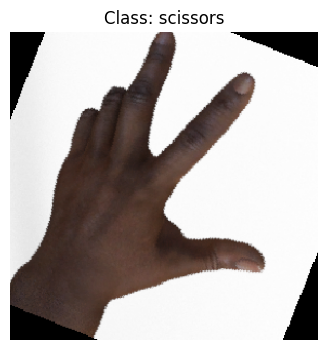

In [11]:
# Verification Step: Fetch a single batch and verify dimensions
def verify_dataloader():
    images, labels = next(iter(train_loader))
    print(f"Batch Images Shape: {images.shape}") # Expected: [32, 3, 300, 300]
    print(f"Batch Labels Shape: {labels.shape}") # Expected: [32]
    print(f"Data Type: {images.dtype}")
    print(f"Min pixel value: {images.min():.4f}, Max pixel value: {images.max():.4f}")
    
    # Optional: Plot the first image to visually confirm augmentations
    plt.figure(figsize=(4, 4))
    # Denormalize to display properly
    img_to_show = images[0].permute(1, 2, 0).numpy() * 0.5 + 0.5
    plt.imshow(img_to_show.clip(0, 1))
    plt.title(f"Class: {train_dataset.classes[labels[0]]}")
    plt.axis('off')
    plt.show()

verify_dataloader()

## Module 2: "Deep-RPS" Custom CNN Architecture
This section defines the 5-block CNN, the training loop with mixed precision (`torch.cuda.amp`), and evaluates the model.

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class DeepRPS(nn.Module):
    def __init__(self):
        super(DeepRPS, self).__init__()
        # Block 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Block 3
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Block 4
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(2, 2)
        
        # Block 5
        self.conv5 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2, 2)
        
        self.dropout = nn.Dropout(0.2)
        
        # Calculate flattened size
        # 300 -> 150 -> 75 -> 37 -> 18 -> 9
        # So it's 512 * 9 * 9
        self.fc1 = nn.Linear(512 * 9 * 9, 512)
        self.fc2 = nn.Linear(512, 3) # 3 classes: Rock, Paper, Scissors

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.pool5(F.relu(self.bn5(self.conv5(x))))
        
        x = x.view(-1, 512 * 9 * 9)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x) # Raw logits for CrossEntropyLoss
        return x

model = DeepRPS()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Model initialized and moved to: {device}")

Model initialized and moved to: cuda


In [13]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler (Reduce LR on plateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

# Mixed Precision Scaler for RTX 4050
scaler = torch.amp.GradScaler('cuda')

c:\CODING\rockpaper\myenv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [14]:
import time

epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Starting Training...")
for epoch in range(epochs):
    start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        # Mixed precision backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val
    
    # Step scheduler
    scheduler.step(epoch_val_loss)
    
    # Save metrics for plotting
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    epoch_duration = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}] Time: {epoch_duration:.1f}s | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

print("Training Complete!")

Starting Training...
Epoch [1/10] Time: 34.6s | Train Loss: 7.8125, Acc: 0.3516 | Val Loss: 1.1952, Acc: 0.3333
Epoch [2/10] Time: 32.1s | Train Loss: 0.8598, Acc: 0.5810 | Val Loss: 0.8288, Acc: 0.6855
Epoch [3/10] Time: 33.0s | Train Loss: 0.2351, Acc: 0.9155 | Val Loss: 0.4278, Acc: 0.8575
Epoch [4/10] Time: 32.4s | Train Loss: 0.0659, Acc: 0.9810 | Val Loss: 0.4945, Acc: 0.8306
Epoch [5/10] Time: 33.0s | Train Loss: 0.0355, Acc: 0.9901 | Val Loss: 0.5101, Acc: 0.8522
Epoch [6/10] Time: 32.1s | Train Loss: 0.0355, Acc: 0.9885 | Val Loss: 0.4296, Acc: 0.8710
Epoch [7/10] Time: 31.9s | Train Loss: 0.0157, Acc: 0.9964 | Val Loss: 0.3678, Acc: 0.8844
Epoch [8/10] Time: 31.6s | Train Loss: 0.0066, Acc: 0.9988 | Val Loss: 0.4743, Acc: 0.8629
Epoch [9/10] Time: 31.5s | Train Loss: 0.0127, Acc: 0.9956 | Val Loss: 0.3851, Acc: 0.8925
Epoch [10/10] Time: 33.4s | Train Loss: 0.0086, Acc: 0.9972 | Val Loss: 0.3858, Acc: 0.9032
Training Complete!


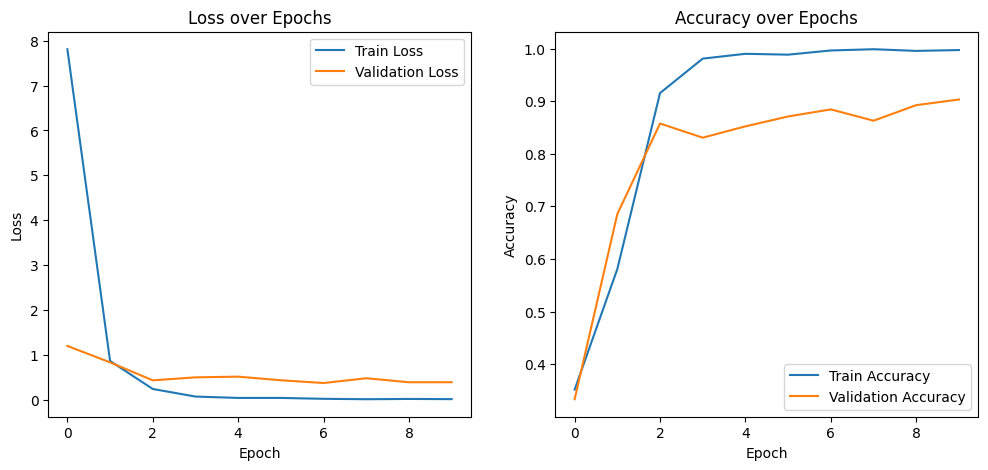

Model weights saved to deep_rps_model.pth


In [15]:
# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Save the trained weights
save_path = "deep_rps_model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model weights saved to {save_path}")